In [2]:
require(tidyverse)
library(dplyr)
library(ggplot2)
#library(psych) 
library(GGally)
options(warn=-1)
options(scipen=999)
#library(crosstable)

In [3]:
path <- "../Compounding/regression/"

varimp_10_files_list  <- path %>% 
  
  # get csvs full paths. (?i) is for case insentitive
  list.files(pattern = "varimp_10_.*Aware.*\\.csv$", full.names = TRUE)

varimp_10_files_agnostic_list  <- path %>% 
  
  # get csvs full paths. (?i) is for case insentitive
  list.files(pattern = "varimp_10000_.*Agnostic.*\\.csv$", full.names = TRUE)

In [13]:
varimp_10_df<-Reduce(bind_rows,lapply(varimp_10_files_list,read.csv))

varimp_10_df %>% dim()

varimp_10_agnostic_df <-Reduce(bind_rows,lapply(varimp_10_files_agnostic_list,read.csv))

[1] 1620  884

In [14]:
varimp_10_df[is.na(varimp_10_df)] <- 0
statistics_varimp_df<-varimp_10_df %>% select(-features) %>% group_by(corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff) %>% 
summarise_all(mean)

In [16]:
varimp_10_agnostic_df[is.na(varimp_10_agnostic_df)] <- 0
statistics_varimp_agnostic_df<-varimp_10_agnostic_df %>% select(-features) %>% group_by(corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff) %>% 
summarise_all(mean)

In [17]:
varimp_10_df %>% head()

,corpus,tag,ppmi,setting,timespan,cutoff,impute,dataset,pattern,features,...,sim_with_head.1820,sim_with_modifier.1820,change_comp.1830,change_comp.1840,change_comp.1850,change_comp.1860,change_comp.1870,change_comp.1880,change_comp.1890,perc_type_comp.1890
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,coha,Tagged,PPMI,Aware,10,0,med,cordeiro100,an,all,...,0,0,0,0,0,0,0,0,0,0
2,coha,Tagged,PPMI,Aware,10,0,med,cordeiro100,an,all,...,0,0,0,0,0,0,0,0,0,0
3,coha,Tagged,PPMI,Aware,10,0,med,cordeiro100,an,all,...,0,0,0,0,0,0,0,0,0,0
4,coha,Tagged,PPMI,Aware,10,0,med,cordeiro100,an,all,...,0,0,0,0,0,0,0,0,0,0
5,coha,Tagged,PPMI,Aware,10,0,med,cordeiro100,an,all,...,0,0,0,0,0,0,0,0,0,0
6,coha,Tagged,PPMI,Aware,10,0,med,cordeiro100,an,all,...,0,0,0,0,0,0,0,0,0,0


In [18]:
statistics_varimp_pivoted_df<-statistics_varimp_df %>% select(!c(n,seed,ml_algo)) %>%
  pivot_longer(!c('corpus','tag','ppmi','setting','timespan','cutoff','impute','dataset','pattern','y'), names_to = "feature_time", values_to = "value")

statistics_varimp_agnostic_pivoted_df<-statistics_varimp_agnostic_df %>% select(!c(n,seed,ml_algo)) %>%
  pivot_longer(!c('corpus','tag','ppmi','setting','timespan','cutoff','impute','dataset','pattern','y'), names_to = "feature_time", values_to = "value")


In [19]:
statistics_varimp_pivoted_df<-statistics_varimp_pivoted_df %>% separate(col=feature_time,into=c('feature', 'time'), sep='\\.',remove=FALSE)

statistics_varimp_agnostic_pivoted_df<-statistics_varimp_agnostic_pivoted_df %>% separate(col=feature_time,into=c('feature', 'time'), sep='\\.',remove=FALSE)


In [20]:
cordeiro_cols<-c('arith_mean_sim.','beta.','geom_mean_sim.','sim_cpf_0.','sim_cpf_100.','sim_cpf_25.','sim_cpf_50.','sim_cpf_75.','sim_cpf_beta.')
cosine_sim_cols<-c("sim_bw_constituents.",'sim_with_head.','sim_with_modifier.')

with_setting_cols<-c("sim_bw_settings_comp.","sim_bw_settings_head.","sim_bw_settings_modifier.",'perc_token_modifier.','perc_type_modifier.','perc_token_head.','perc_type_head.','perc_token_comp.','perc_type_comp.')
info_theory_cols<-c("local_mi.","log_ratio.","ppmi.")
freq_cols<-c("comp_freq.","comp_tf.","head_freq.","head_tf.","log_comp_freq.","log_head_freq.","log_head_freq_new.","log_mod_freq.","log_mod_freq_new.","mod_freq.","mod_tf.")
prod_cols<-c("head_family_size.","head_family_size_new.","head_prod.","mod_family_size.","mod_family_size_new.","mod_prod.")
change_cols<-c('change_comp.','change_mod.','change_head.')

In [21]:
statistics_varimp_pivoted_df$feature<-paste0(statistics_varimp_pivoted_df$feature,".")
statistics_varimp_pivoted_df$feature_class<-""
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  cordeiro_cols] <- "cordeiro"
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  cosine_sim_cols] <- "cosine_sim"
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  with_setting_cols] <- "with_setting"
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  info_theory_cols] <- "info_theory"
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  freq_cols] <- "freq"
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  prod_cols] <- "prod"
statistics_varimp_pivoted_df$feature_class[statistics_varimp_pivoted_df$feature %in%  change_cols] <- "temp_change"
head(statistics_varimp_pivoted_df)


statistics_varimp_agnostic_pivoted_df$feature<-paste0(statistics_varimp_agnostic_pivoted_df$feature,".")
statistics_varimp_agnostic_pivoted_df$feature_class<-""
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  cordeiro_cols] <- "cordeiro"
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  cosine_sim_cols] <- "cosine_sim"
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  with_setting_cols] <- "with_setting"
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  info_theory_cols] <- "info_theory"
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  freq_cols] <- "freq"
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  prod_cols] <- "prod"
statistics_varimp_agnostic_pivoted_df$feature_class[statistics_varimp_agnostic_pivoted_df$feature %in%  change_cols] <- "temp_change"
head(statistics_varimp_agnostic_pivoted_df)

corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff,feature_time,feature,time,value,feature_class
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>
coha,Tagged,PPMI,Aware,med,cordeiro100,compound,an,10,0,arith_mean_sim.1830,arith_mean_sim.,1830,20.805876,cordeiro
coha,Tagged,PPMI,Aware,med,cordeiro100,compound,an,10,0,arith_mean_sim.1840,arith_mean_sim.,1840,20.526956,cordeiro
coha,Tagged,PPMI,Aware,med,cordeiro100,compound,an,10,0,arith_mean_sim.1850,arith_mean_sim.,1850,12.658373,cordeiro
coha,Tagged,PPMI,Aware,med,cordeiro100,compound,an,10,0,arith_mean_sim.1860,arith_mean_sim.,1860,2.729043,cordeiro
coha,Tagged,PPMI,Aware,med,cordeiro100,compound,an,10,0,arith_mean_sim.1870,arith_mean_sim.,1870,6.562403,cordeiro
coha,Tagged,PPMI,Aware,med,cordeiro100,compound,an,10,0,arith_mean_sim.1880,arith_mean_sim.,1880,4.312980,cordeiro


corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff,feature_time,feature,time,value,feature_class
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>
coha,Tagged,PPMI,Agnostic,med,cordeiro100,compound,an,10000,0,arith_mean_sim.0,arith_mean_sim.,0,13.840963,cordeiro
coha,Tagged,PPMI,Agnostic,med,cordeiro100,compound,an,10000,0,beta.0,beta.,0,13.270600,cordeiro
coha,Tagged,PPMI,Agnostic,med,cordeiro100,compound,an,10000,0,comp_freq.0,comp_freq.,0,7.821638,freq
coha,Tagged,PPMI,Agnostic,med,cordeiro100,compound,an,10000,0,comp_tf.0,comp_tf.,0,15.994584,freq
coha,Tagged,PPMI,Agnostic,med,cordeiro100,compound,an,10000,0,geom_mean_sim.0,geom_mean_sim.,0,96.099683,cordeiro
coha,Tagged,PPMI,Agnostic,med,cordeiro100,compound,an,10000,0,head_family_size.0,head_family_size.,0,25.705284,prod


In [22]:
a_df<-statistics_varimp_pivoted_df %>% filter(dataset=="reddy") %>% group_by(feature_class,y) %>% summarize(mean(value), sd(value))
a_df

`summarise()` has grouped output by 'feature_class'. You can override using the `.groups` argument.


feature_class,y,mean(value),sd(value)
<chr>,<chr>,<dbl>,<dbl>
cordeiro,compound,1.730726,5.941552
cordeiro,head,3.917708,7.765323
cordeiro,modifier,3.465495,8.478567
cosine_sim,compound,4.263634,11.329963
cosine_sim,head,5.376908,10.461742
cosine_sim,modifier,7.130667,13.840974
freq,compound,2.560859,9.827636
freq,head,4.259269,10.135368
freq,modifier,3.683127,9.755233


In [23]:
b_df<-statistics_varimp_agnostic_pivoted_df %>% filter(dataset=="reddy") %>% group_by(feature_class,y) %>% summarize(mean(value), sd(value))
b_df

`summarise()` has grouped output by 'feature_class'. You can override using the `.groups` argument.


feature_class,y,mean(value),sd(value)
<chr>,<chr>,<dbl>,<dbl>
cordeiro,compound,10.730306,13.90710
cordeiro,head,16.011754,18.35315
cordeiro,modifier,13.108852,18.89416
cosine_sim,compound,19.092963,22.30362
cosine_sim,head,22.029269,24.34653
cosine_sim,modifier,15.927281,17.89594
freq,compound,19.680421,26.24338
freq,head,23.106557,26.52985
freq,modifier,17.725856,24.04092


In [24]:
statistics_varimp_pivoted_df %>% group_by(feature) %>% summarize(mv=mean(value))  %>% arrange(desc(mv))


feature,mv
<chr>,<dbl>
sim_bw_constituents.,12.878491
sim_bw_settings_head.,9.551019
change_head.,6.985940
change_comp.,6.721229
change_mod.,5.998448
sim_bw_settings_modifier.,5.838868
comp_tf.,5.229004
log_comp_freq.,5.032755
sim_bw_settings_comp.,4.739388


In [25]:
statistics_varimp_pivoted_df %>% group_by(feature_time) %>% summarize(mv=mean(value))  %>% arrange(desc(mv))


feature_time,mv
<chr>,<dbl>
sim_bw_settings_head.1970,20.02928
sim_bw_constituents.2010,19.95483
sim_bw_constituents.1990,19.80614
sim_bw_constituents.2000,19.65510
sim_bw_constituents.1940,19.53460
sim_bw_settings_head.1980,18.95292
comp_tf.2010,18.33964
change_comp.2010,17.57166
sim_bw_constituents.1960,17.54176


In [26]:
statistics_varimp_pivoted_df %>% group_by(time) %>% summarize(mv=mean(value))  %>% arrange(desc(mv))


time,mv
<chr>,<dbl>
2010,7.621943
2000,7.538916
1990,6.557672
1980,6.087370
1970,5.796527
1960,5.704583
1940,4.893343
1950,4.877641
1930,4.690892


In [37]:
length(rsquared_files_list)

[1] 1956

In [42]:
# in one pipeline:
rsquared_files_list  <- path %>% 
  
  # get csvs full paths. (?i) is for case insentitive
  list.files(pattern = "rsquared_.*\\.csv$", full.names = TRUE)


In [43]:
rsquared_df<-Reduce(rbind,lapply(rsquared_files_list, function(x) {
    if (ncol(read.csv(x))>1) {
       return(read.csv(x))
    }
}))

In [44]:
rsquared_df %>% dim()

[1] 48 14

In [45]:
head(rsquared_df)

,corpus,tag,ppmi,setting,timespan,cutoff,impute,features,y,train_dim,ml_algo,method,TrainRsquared,TrainSpearman
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,coha,UnTagged,PPMI,Agnostic,10000,0,med,all,compound,180,elastic,glmnet,0.3026332,0.5495052
2,coha,UnTagged,PPMI,Agnostic,10000,0,med,cordeiro,compound,180,elastic,glmnet,0.1964560,0.4237935
3,coha,UnTagged,PPMI,Agnostic,10000,0,med,cosine_sim,compound,180,elastic,glmnet,0.1356972,0.3710414
4,coha,UnTagged,PPMI,Agnostic,10000,0,na,all,compound,167,elastic,glmnet,0.3231600,0.5605147
5,coha,UnTagged,PPMI,Agnostic,10000,0,na,cordeiro,compound,167,elastic,glmnet,0.2038424,0.4448247
6,coha,UnTagged,PPMI,Agnostic,10000,0,na,cosine_sim,compound,167,elastic,glmnet,0.1523281,0.4026757


In [46]:
rsquared_df$cutoff<-as.factor(rsquared_df$cutoff)


In [48]:
statistics<-rsquared_df %>% group_by(corpus,tag,ppmi,setting,impute,y,timespan,cutoff,features) %>% 
summarise(n=mean(train_dim),meanRsquared=mean(TrainRsquared),sdRsquared=sd(TrainRsquared),meanCorr=mean(TrainSpearman),sdCorr=sd(TrainSpearman))

statistics   %>% filter(y=="compound") %>% arrange(desc(meanCorr)) %>% head(10)

`summarise()` has grouped output by 'corpus', 'tag', 'ppmi', 'setting', 'impute', 'y', 'timespan', 'cutoff'. You can override using the `.groups` argument.


corpus,tag,ppmi,setting,impute,y,timespan,cutoff,features,n,meanRsquared,sdRsquared,meanCorr,sdCorr
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coha,UnTagged,PPMI,Agnostic,na,compound,10000,0,all,167,0.3231600,NA,0.5605147,NA
coha,UnTagged,PPMI,Agnostic,med,compound,10000,0,all,180,0.3026332,NA,0.5495052,NA
coha,UnTagged,PPMI,Aware,na,compound,10000,0,all,167,0.2684848,NA,0.5079571,NA
coha,UnTagged,PPMI,Aware,med,compound,10000,0,all,180,0.2600548,NA,0.4949069,NA
coha,UnTagged,RAW,Agnostic,na,compound,10000,0,all,168,0.2273986,NA,0.4691153,NA
coha,UnTagged,PPMI,Aware,na,compound,10000,0,log_freq,167,0.2181322,NA,0.4648844,NA
coha,UnTagged,PPMI,Aware,na,compound,10000,0,info_theory,167,0.2773796,NA,0.4633885,NA
coha,UnTagged,RAW,Aware,na,compound,10000,0,info_theory,168,0.2306515,NA,0.4608722,NA
coha,UnTagged,RAW,Aware,na,compound,10000,0,log_freq,168,0.2169883,NA,0.4578048,NA


In [49]:
statistics   %>% filter(n==180) %>% arrange(desc(meanCorr)) %>% head(10)

corpus,tag,ppmi,setting,impute,y,timespan,cutoff,features,n,meanRsquared,sdRsquared,meanCorr,sdCorr
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coha,UnTagged,PPMI,Agnostic,med,compound,10000,0,all,180,0.3026332,NA,0.5495052,NA
coha,UnTagged,PPMI,Aware,med,compound,10000,0,all,180,0.2600548,NA,0.4949069,NA
coha,UnTagged,RAW,Aware,med,compound,10000,0,info_theory,180,0.2166866,NA,0.4510101,NA
coha,UnTagged,RAW,Agnostic,med,compound,10000,0,all,180,0.2125439,NA,0.4382436,NA
coha,UnTagged,PPMI,Aware,med,compound,10000,0,info_theory,180,0.2626373,NA,0.4327322,NA
coha,UnTagged,PPMI,Aware,med,compound,10000,0,cordeiro,180,0.1629353,NA,0.4293461,NA
coha,UnTagged,PPMI,Aware,med,compound,10000,0,log_freq,180,0.2078143,NA,0.4250702,NA
coha,UnTagged,PPMI,Agnostic,med,compound,10000,0,cordeiro,180,0.1964560,NA,0.4237935,NA
coha,UnTagged,RAW,Aware,med,compound,10000,0,log_freq,180,0.1968696,NA,0.4221986,NA


In [36]:
statistics<-rsquared_df %>% group_by(corpus,tag,ppmi,setting,impute,y,timespan,cutoff,features) %>% 
summarise(n=mean(n),meanRsquared=mean(TrainRsquared),sdRsquared=sd(TrainRsquared),meanCorr=mean(TrainSpearman),sdCorr=sd(TrainSpearman))

statistics   %>% filter(y=="compound") %>% arrange(desc(meanCorr)) %>% head(10)

`summarise()` has grouped output by 'corpus', 'tag', 'ppmi', 'setting', 'impute', 'y', 'timespan', 'cutoff'. You can override using the `.groups` argument.


corpus,tag,ppmi,setting,impute,y,timespan,cutoff,features,n,meanRsquared,sdRsquared,meanCorr,sdCorr
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coha,UnTagged,PPMI,Agnostic,na,compound,10000,0,all,167,0.3475192,0.01654730,0.5776099,0.01250576
coha,UnTagged,PPMI,Agnostic,med,compound,10000,0,all,180,0.3318693,0.01534111,0.5484679,0.01914635
coha,UnTagged,PPMI,Aware,na,compound,10000,0,all,167,0.3097452,0.01479661,0.5456886,0.02038150
coha,UnTagged,PPMI,Aware,med,compound,10000,0,all,180,0.2943630,0.01209952,0.5012421,0.01364642
coha,UnTagged,RAW,Agnostic,na,compound,10000,0,all,168,0.2577114,0.01164549,0.4800515,0.01560263
coha,UnTagged,PPMI,Aware,na,compound,10000,0,info_theory,167,0.3036767,0.01632236,0.4707957,0.01563312
coha,UnTagged,RAW,Aware,na,compound,10000,0,all,168,0.2470254,0.01435275,0.4705846,0.01751297
coha,UnTagged,RAW,Aware,na,compound,10000,0,log_freq,168,0.2469506,0.02198100,0.4695658,0.01985566
coha,UnTagged,PPMI,Aware,na,compound,10000,0,log_freq,167,0.2495621,0.01515195,0.4677354,0.01494621


In [37]:
statistics   %>% filter(n==180) %>% arrange(desc(meanCorr)) %>% head(10)

corpus,tag,ppmi,setting,impute,y,timespan,cutoff,features,n,meanRsquared,sdRsquared,meanCorr,sdCorr
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coha,UnTagged,PPMI,Agnostic,med,compound,10000,0,all,180,0.3318693,0.01534111,0.5484679,0.01914635
coha,UnTagged,PPMI,Aware,med,compound,10000,0,all,180,0.2943630,0.01209952,0.5012421,0.01364642
coha,UnTagged,PPMI,Aware,med,compound,10000,0,cordeiro,180,0.1975856,0.02134801,0.4409715,0.02392834
coha,UnTagged,PPMI,Aware,med,compound,10000,0,info_theory,180,0.2892310,0.01538534,0.4400587,0.01881542
coha,UnTagged,RAW,Aware,med,compound,10000,0,info_theory,180,0.2351470,0.01654124,0.4399221,0.02580695
coha,UnTagged,RAW,Agnostic,med,compound,10000,0,all,180,0.2562935,0.01167746,0.4291353,0.01745355
coha,UnTagged,PPMI,Aware,med,compound,10000,0,log_freq,180,0.2426899,0.02231725,0.4284980,0.01749171
coha,UnTagged,PPMI,Agnostic,med,compound,10000,0,cordeiro,180,0.2259553,0.01674582,0.4251734,0.01908596
coha,UnTagged,PPMI,Aware,med,compound,10000,0,freq,180,0.2717879,0.01075824,0.4214509,0.02326144


In [41]:
rsquared_df %>% group_by(features) %>% summarize(mean(TrainSpearman))

features,mean(TrainSpearman)
<chr>,<dbl>
all,0.4955840
cordeiro,0.3901616
cosine_sim,0.3428105
family_size,0.3293412
freq,0.4344807
info_theory,0.4541036
log_freq,0.4465739
prod,0.2991009
with_setting,0.0333088


In [57]:
statistics  %>% filter(y =="head") %>% arrange(desc(meanCorr)) %>% head(10)



corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff,n,meanRsquared,sdRsquared,meanCorr,sdCorr,mean_feat
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coha,Tagged,PPMI,Aware,med,reddy,head,an,10000,0,90,0.3942677,0.01049229,0.6429805,0.04372483,23
coha,Tagged,PPMI,Aware,med,reddy,head,nn,10000,0,90,0.3881692,0.02113056,0.6377822,0.04477442,23
coha,UnTagged,PPMI,Aware,med,reddy,head,all,20,0,90,0.3898073,0.02305317,0.6328791,0.02214863,58
coha,UnTagged,PPMI,Aware,med,reddy,head,all,10000,10,90,0.3922828,0.03191822,0.6245614,0.07183329,22
coha,UnTagged,PPMI,Aware,med,reddy,head,all,10,10,90,0.3575721,0.02067345,0.6177642,0.03447004,336
coha,UnTagged,PPMI,Aware,med,reddy,head,all,10,50,90,0.3363860,0.02778584,0.6177437,0.03144786,77
coha,Tagged,PPMI,Agnostic,na,reddy,head,an,10000,0,90,0.3334209,0.02978859,0.6170610,0.04683028,24
coha,UnTagged,PPMI,Agnostic,na,cordeiro90,head,all,10000,0,90,0.4303072,0.02759009,0.6157533,0.04063282,27
coha,UnTagged,PPMI,Aware,med,reddy,head,all,20,10,90,0.3391732,0.02720932,0.6153069,0.02614976,286


In [58]:
statistics  %>% filter(y =="modifier" ) %>% arrange(desc(meanCorr)) %>% head(10)

corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff,n,meanRsquared,sdRsquared,meanCorr,sdCorr,mean_feat
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coha,UnTagged,PPMI,Agnostic,na,reddy,modifier,all,10000,0,90,0.5422469,0.02487431,0.7177026,0.04327459,19
coha,UnTagged,PPMI,Agnostic,med,reddy,modifier,all,10000,0,90,0.5135744,0.02186858,0.6817501,0.02528562,19
coha,UnTagged,PPMI,Aware,med,reddy,modifier,all,10,500,90,0.3715067,0.04084832,0.6321637,0.02704950,54
coha,UnTagged,PPMI,Agnostic,med,reddy,modifier,all,10000,10,90,0.4110579,0.04142970,0.6291377,0.03326234,30
coha,UnTagged,PPMI,Agnostic,na,reddy,modifier,all,10000,10,90,0.4188012,0.02353295,0.6193068,0.02717753,18
coha,UnTagged,PPMI,Aware,med,reddy,modifier,all,10000,100,90,0.4236325,0.02983772,0.6120570,0.03853948,34
coha,UnTagged,PPMI,Agnostic,na,reddy,modifier,all,10000,100,90,0.4318557,0.01989044,0.6110507,0.03166910,23
coha,Tagged,PPMI,Aware,med,reddy,modifier,an,10000,0,90,0.4018888,0.03614057,0.5988751,0.02298141,25
coha,UnTagged,PPMI,Agnostic,na,reddy,modifier,all,10,1000,85,0.3787774,0.03284868,0.5983084,0.03695662,38


In [59]:
summary(aov(mean_feat~y, data = statistics))

              Df   Sum Sq Mean Sq F value     Pr(>F)    
y              2   302333  151166   12.84 0.00000292 ***
Residuals   1767 20808369   11776                       
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [60]:
summary(aov(meanCorr~tag, data = statistics))

              Df Sum Sq Mean Sq F value              Pr(>F)    
tag            1  1.136  1.1357   72.09 <0.0000000000000002 ***
Residuals   1768 27.854  0.0158                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [61]:
summary(aov(meanCorr~ppmi, data = statistics))

ERROR: Error in `contrasts<-`(`*tmp*`, value = contr.funs[1 + isOF[nn]]): contrasts can be applied only to factors with 2 or more levels


In [191]:
summary(aov(meanCorr~setting, data = statistics))

              Df Sum Sq Mean Sq F value Pr(>F)
setting        1   0.03 0.02668   2.165  0.141
Residuals   5649  69.62 0.01232               

In [192]:
summary(aov(meanCorr~timespan, data = statistics))

              Df Sum Sq Mean Sq F value Pr(>F)  
timespan       1   0.04 0.03653   2.965 0.0852 .
Residuals   5649  69.61 0.01232                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [193]:
summary(aov(meanCorr~cutoff, data = statistics))

              Df Sum Sq Mean Sq F value     Pr(>F)    
cutoff         5   0.40 0.08028   6.544 0.00000445 ***
Residuals   5645  69.25 0.01227                       
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [194]:
summary(aov(meanCorr~timespan*cutoff, data = statistics))

                  Df Sum Sq Mean Sq F value     Pr(>F)    
timespan           1   0.04 0.03653   2.988   0.083931 .  
cutoff             5   0.39 0.07865   6.433 0.00000573 ***
timespan:cutoff    5   0.28 0.05501   4.499   0.000428 ***
Residuals       5639  68.94 0.01223                       
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

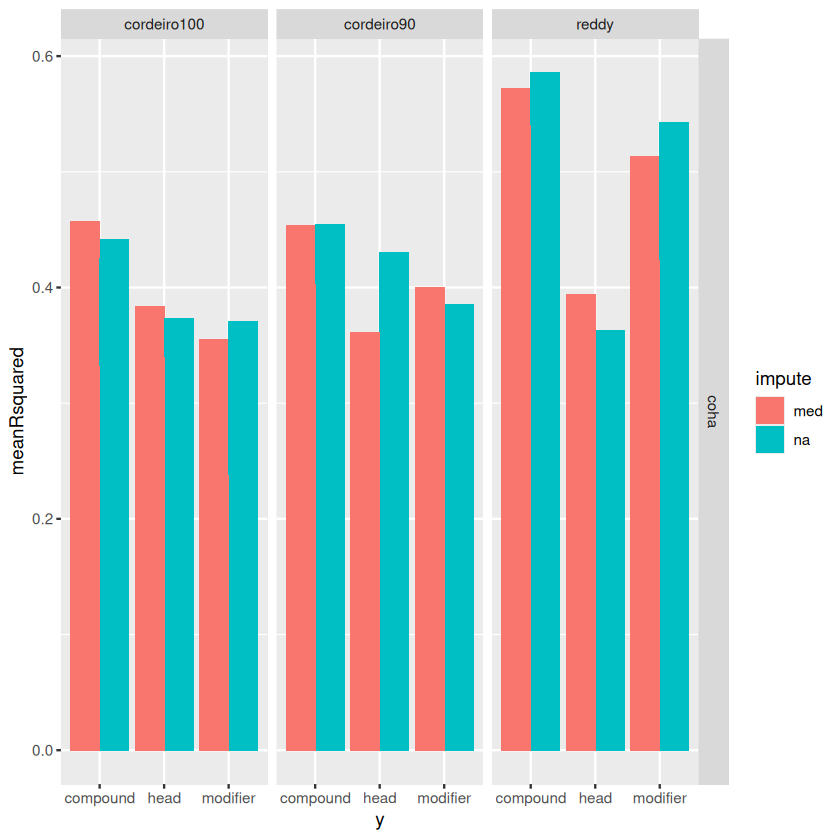

In [62]:
statistics %>% ggplot(aes(x=meanRsquared,y=y,fill=impute)) + facet_grid(corpus~dataset) +geom_bar(stat='identity',position = "dodge")  + 
coord_flip()

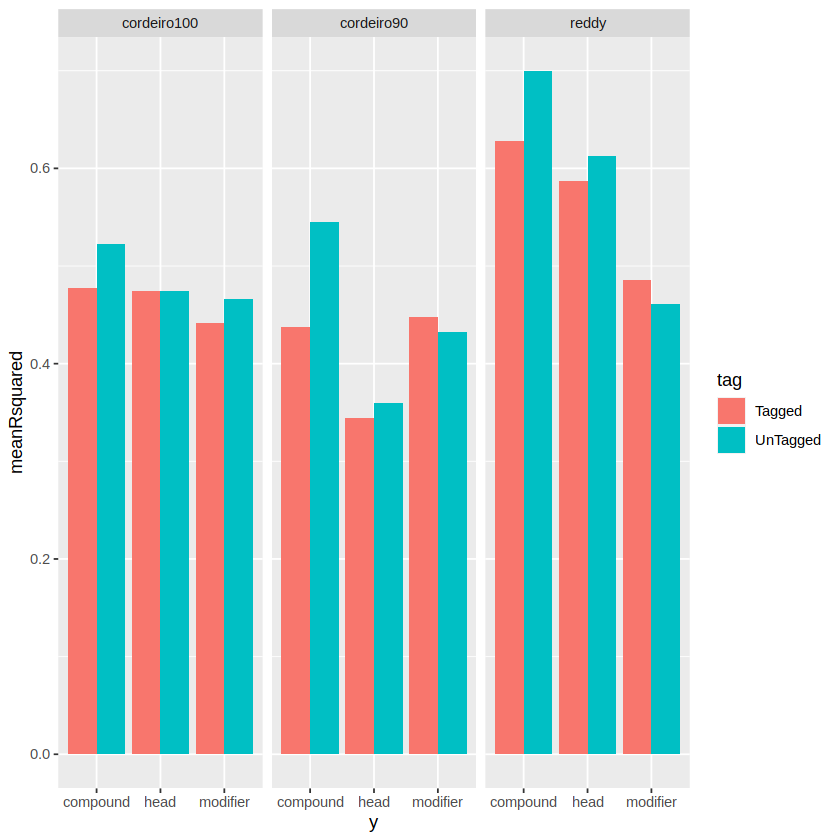

In [196]:
statistics %>%  ggplot(aes(x=meanRsquared,y=y,fill=tag)) + facet_grid(~dataset) +geom_bar(stat='identity',position = "dodge")  + 
coord_flip()

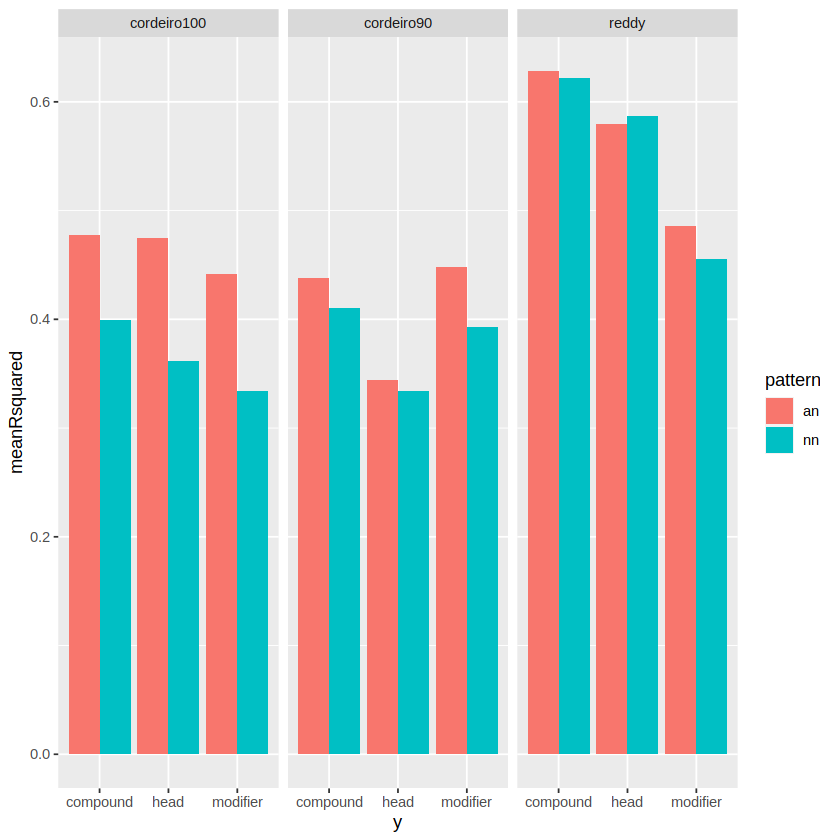

In [197]:
statistics %>% filter(tag=="Tagged") %>% ggplot(aes(x=meanRsquared,y=y,fill=pattern)) + facet_grid(~dataset) +geom_bar(stat='identity',position = "dodge")  + 
coord_flip()

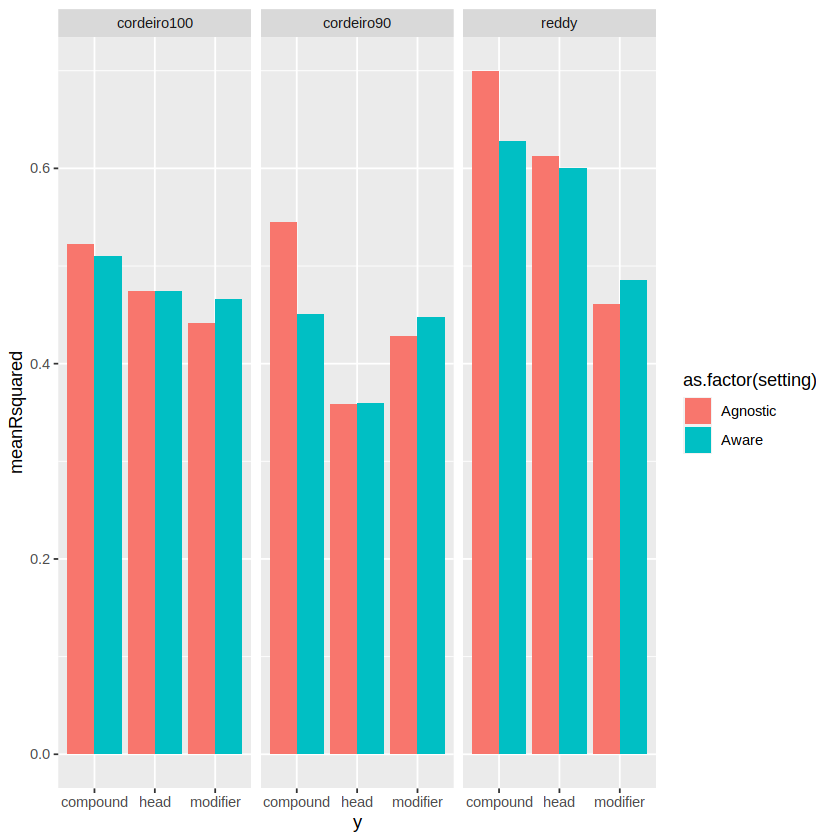

In [198]:
statistics %>% ggplot(aes(x=meanRsquared,y=y,fill=as.factor(setting))) + facet_grid(~dataset) +geom_bar(stat='identity',position = "dodge")  + 
coord_flip()

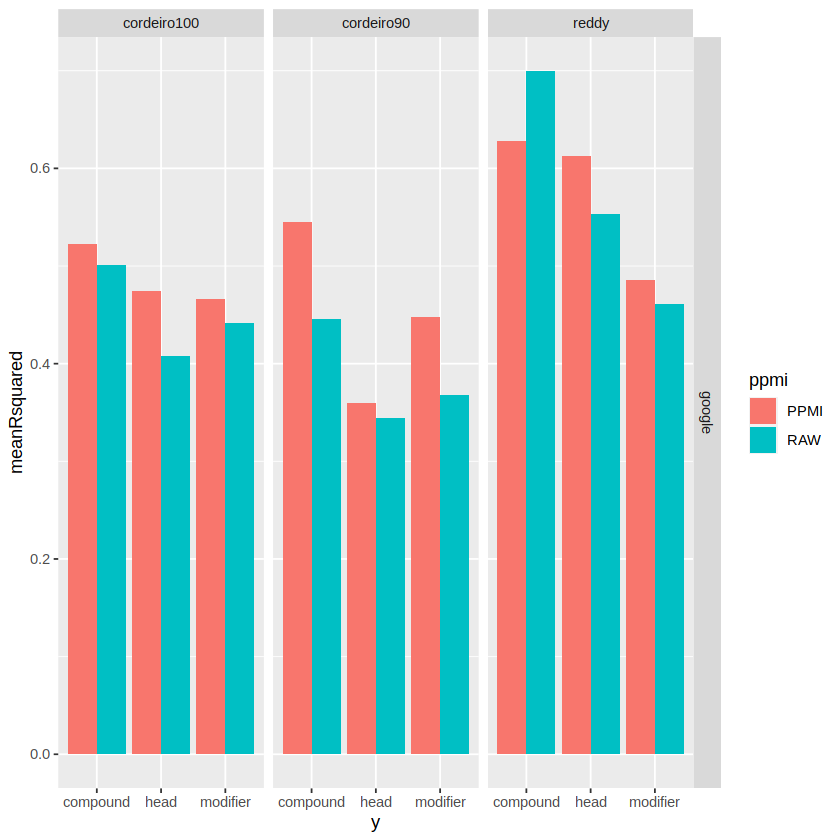

In [199]:
statistics %>% ggplot(aes(x=meanRsquared,y=y,fill=ppmi)) + facet_grid(corpus~dataset) +geom_bar(stat='identity',position = "dodge")  + 
coord_flip()

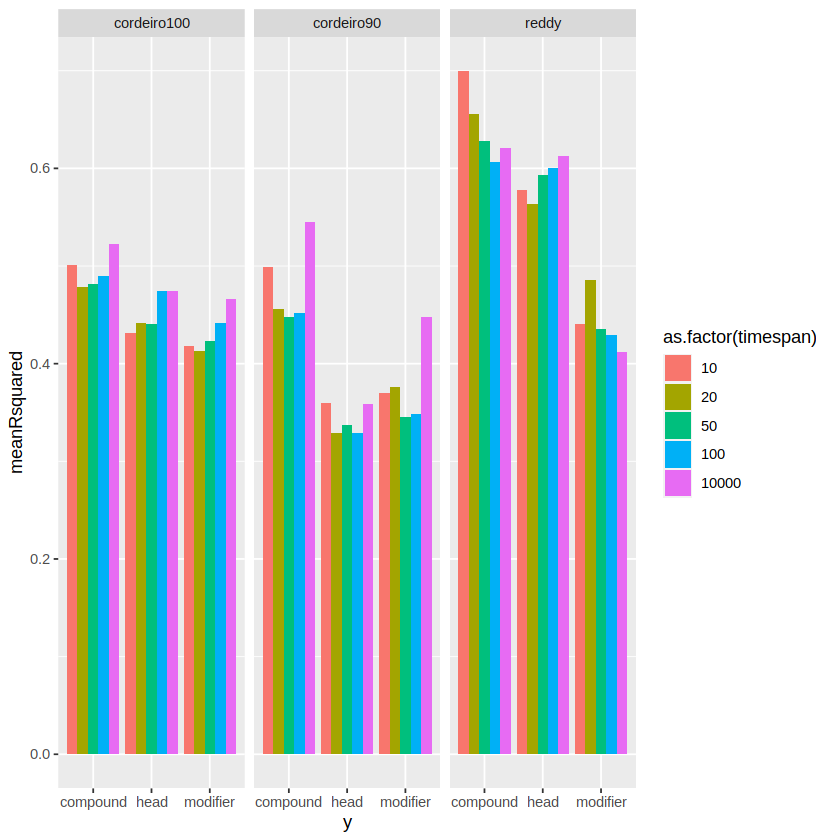

In [200]:
statistics %>% ggplot(aes(x=meanRsquared,y=y,fill=as.factor(timespan))) + facet_grid(~dataset) +geom_bar(stat='identity',position = "dodge")  + 
coord_flip()

In [201]:
statistics_varimp_pivoted_df %>% filter(tag=="UnTagged" & ppmi=="RAW" & setting=="Agnostic" & impute=="na" & dataset=="reddy") #& compound

corpus,tag,ppmi,setting,impute,dataset,y,pattern,timespan,cutoff,feature_time,feature,time,value,feature_class
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>
